# Hyperparameter Tuning — Random Forest & SVM
### Parameters vs Hyperparameters, Manual Sweeps, and GridSearchCV




## 0. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Dataset — Gaming: Predicting Player Churn



In [ ]:
n = 2000
sessions_per_week = np.random.poisson(5, n)
avg_session_minutes = np.random.normal(25, 12, n).clip(1, 120)
in_game_purchases = np.random.poisson(1.5, n)
player_level = np.random.randint(1, 100, n)
days_since_last_login = np.random.exponential(3, n).clip(0, 60)

churn_score = (
    -0.9 * sessions_per_week
    - 0.05 * avg_session_minutes
    - 1.0 * in_game_purchases
    - 0.035 * player_level
    + 0.7 * days_since_last_login
    + 4.4
)
churn_prob = 1 / (1 + np.exp(-churn_score))
churned = (np.random.rand(n) < churn_prob).astype(int)

df = pd.DataFrame({
    "SessionsPerWeek": sessions_per_week, "AvgSessionMinutes": avg_session_minutes,
    "InGamePurchases": in_game_purchases, "PlayerLevel": player_level,
    "DaysSinceLastLogin": days_since_last_login, "Churned": churned
})
print("Churn rate:", round(df["Churned"].mean(), 4))
df.head()

Churn rate: 0.237


,SessionsPerWeek,AvgSessionMinutes,InGamePurchases,PlayerLevel,DaysSinceLastLogin,Churned
0,5,45.239816,2,78,1.204830,0
1,4,16.718310,4,34,3.901709,0
2,4,34.291493,1,19,2.934847,0
3,5,33.507237,0,70,0.819435,0
4,5,1.000000,2,82,2.769664,0


In [ ]:
X = df.drop(columns=["Churned"])
y = df["Churned"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 1600  Test size: 400



## 2. Model 1 — Random Forest




### 2.2 Baseline Model (default hyperparameters)

In [ ]:
rf_default = RandomForestClassifier(random_state=42)  # n_estimators=100, max_depth=None by default
rf_default.fit(X_train, y_train)
baseline_rf_acc = accuracy_score(y_test, rf_default.predict(X_test))
print(f"Baseline Random Forest (default hyperparameters) Accuracy: {baseline_rf_acc:.4f}")

Baseline Random Forest (default hyperparameters) Accuracy: 0.8825


### 2.3 Manual Hyperparameter Sweep — Effect of `n_estimators`

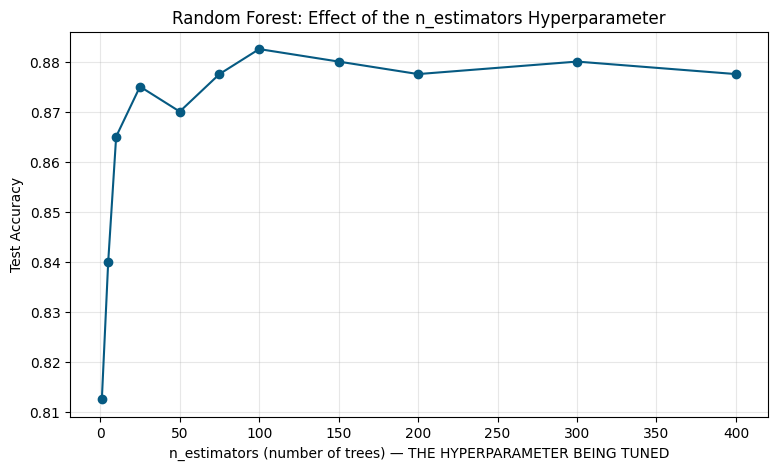

In [ ]:
n_estimators_values = [1, 5, 10, 25, 50, 75, 100, 150, 200, 300, 400]
test_acc_trees = []

for n in n_estimators_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    test_acc_trees.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_estimators_values, test_acc_trees, marker="o", color="#065A82")
plt.xlabel("n_estimators (number of trees) — THE HYPERPARAMETER BEING TUNED")
plt.ylabel("Test Accuracy")
plt.title("Random Forest: Effect of the n_estimators Hyperparameter")
plt.grid(alpha=0.3)
plt.show()

### 2.4 Manual Hyperparameter Sweep — Effect of `max_depth`

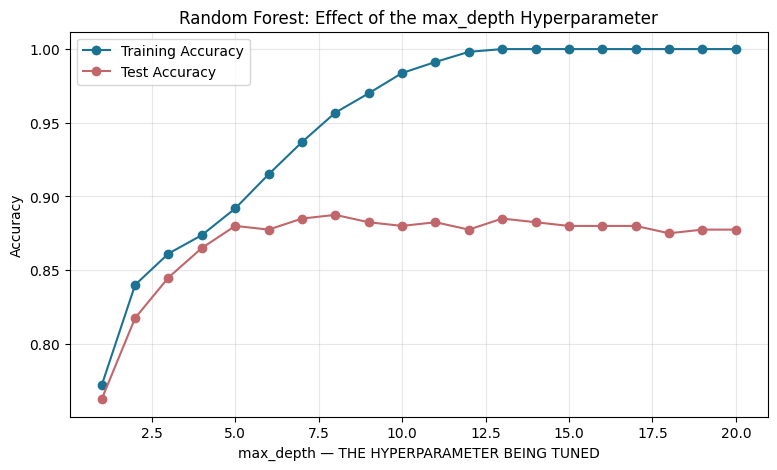

In [ ]:
depth_values = range(1, 21)
train_acc, test_acc = [], []

for d in depth_values:
    model = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(list(depth_values), train_acc, marker="o", label="Training Accuracy", color="#1C7293")
plt.plot(list(depth_values), test_acc, marker="o", label="Test Accuracy", color="#C1666B")
plt.xlabel("max_depth — THE HYPERPARAMETER BEING TUNED")
plt.ylabel("Accuracy")
plt.title("Random Forest: Effect of the max_depth Hyperparameter")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2.5 Systematic Tuning — GridSearchCV

In [ ]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10, None],
    "max_features": ["sqrt", "log2"],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best Random Forest hyperparameters found:", rf_grid.best_params_)
print(f"Best cross-validation accuracy: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
tuned_rf_acc = accuracy_score(y_test, rf_best.predict(X_test))
print(f"\nTest Accuracy -> Default hyperparameters: {baseline_rf_acc:.4f}")
print(f"Test Accuracy -> Tuned hyperparameters:   {tuned_rf_acc:.4f}")

Best Random Forest hyperparameters found: {'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 100}
Best cross-validation accuracy: 0.8713

Test Accuracy -> Default hyperparameters: 0.8825
Test Accuracy -> Tuned hyperparameters:   0.8825


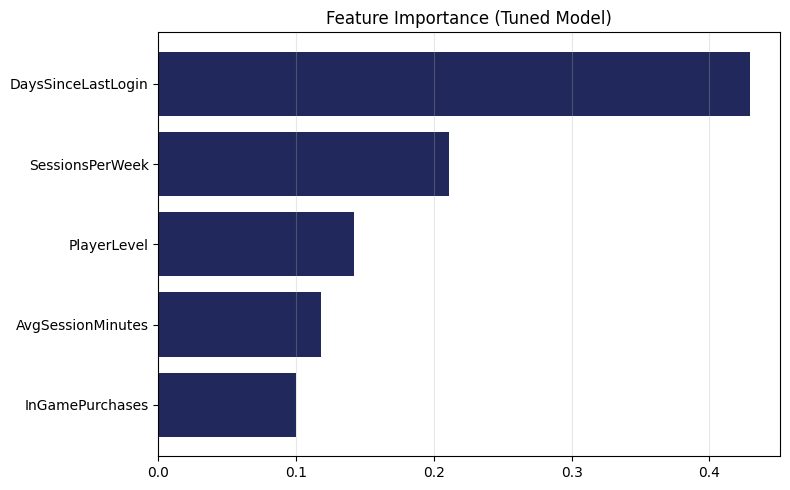

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

importances = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
).sort_values()

ax.barh(importances.index, importances.values, color="#21295C")
ax.set_title("Feature Importance (Tuned Model)")
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

---
## 3. Model 2 — Support Vector Machine (SVM)




### 3.2 Baseline Model (default hyperparameters)

In [ ]:
svm_default = SVC(probability=True, random_state=42)  # C=1.0, gamma="scale", kernel="rbf" by default
svm_default.fit(X_train_s, y_train)
baseline_svm_acc = accuracy_score(y_test, svm_default.predict(X_test_s))
print(f"Baseline SVM (default hyperparameters) Accuracy: {baseline_svm_acc:.4f}")

Baseline SVM (default hyperparameters) Accuracy: 0.8900


### 3.3 Manual Hyperparameter Sweep — Effect of `C`

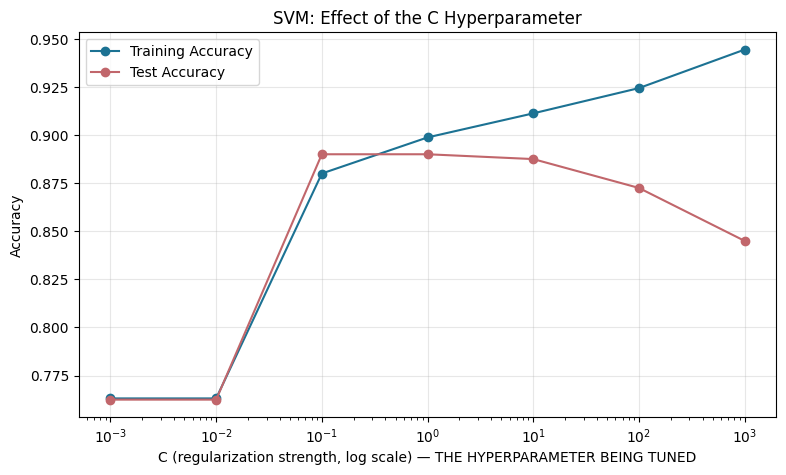

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_acc, test_acc = [], []

for c in C_values:
    model = SVC(C=c, kernel="rbf", random_state=42)
    model.fit(X_train_s, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train_s)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test_s)))

plt.figure(figsize=(9, 5))
plt.plot(C_values, train_acc, marker="o", label="Training Accuracy", color="#1C7293")
plt.plot(C_values, test_acc, marker="o", label="Test Accuracy", color="#C1666B")
plt.xscale("log")
plt.xlabel("C (regularization strength, log scale) — THE HYPERPARAMETER BEING TUNED")
plt.ylabel("Accuracy")
plt.title("SVM: Effect of the C Hyperparameter")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.4 Manual Hyperparameter Sweep — Effect of `gamma`

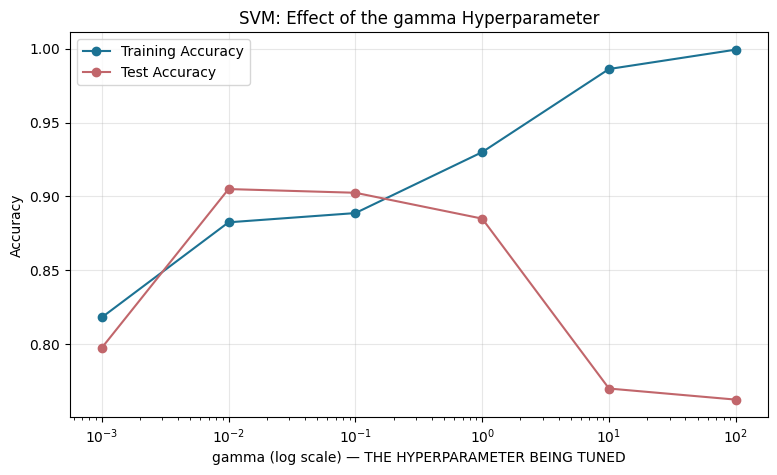

In [ ]:
gamma_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_acc, test_acc = [], []

for g in gamma_values:
    model = SVC(C=1, kernel="rbf", gamma=g, random_state=42)
    model.fit(X_train_s, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train_s)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test_s)))

plt.figure(figsize=(9, 5))
plt.plot(gamma_values, train_acc, marker="o", label="Training Accuracy", color="#1C7293")
plt.plot(gamma_values, test_acc, marker="o", label="Test Accuracy", color="#C1666B")
plt.xscale("log")
plt.xlabel("gamma (log scale) — THE HYPERPARAMETER BEING TUNED")
plt.ylabel("Accuracy")
plt.title("SVM: Effect of the gamma Hyperparameter")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.5 Systematic Tuning — GridSearchCV

In [ ]:
svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"],
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
svm_grid.fit(X_train_s, y_train)

print("Best SVM hyperparameters found:", svm_grid.best_params_)
print(f"Best cross-validation accuracy: {svm_grid.best_score_:.4f}")

svm_best = svm_grid.best_estimator_
tuned_svm_acc = accuracy_score(y_test, svm_best.predict(X_test_s))
print(f"\nTest Accuracy -> Default hyperparameters: {baseline_svm_acc:.4f}")
print(f"Test Accuracy -> Tuned hyperparameters:   {tuned_svm_acc:.4f}")

Best SVM hyperparameters found: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.8906

Test Accuracy -> Default hyperparameters: 0.8900
Test Accuracy -> Tuned hyperparameters:   0.8975


---
## 4. Summary — Default vs. Tuned Hyperparameters


In [ ]:
summary = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Default Hyperparameters Accuracy": [baseline_rf_acc, baseline_svm_acc],
    "Tuned Hyperparameters Accuracy": [tuned_rf_acc, tuned_svm_acc],
    "Best Hyperparameters Found": [str(rf_grid.best_params_), str(svm_grid.best_params_)]
})
summary["Improvement"] = summary["Tuned Hyperparameters Accuracy"] - summary["Default Hyperparameters Accuracy"]
summary

,Model,Default Hyperparameters Accuracy,Tuned Hyperparameters Accuracy,Best Hyperparameters Found,Improvement
0,Random Forest,0.8825,0.8825,"{'max_depth': 8, 'max_features': 'sqrt', 'n_es...",0.0000
1,SVM,0.8900,0.8975,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.0075


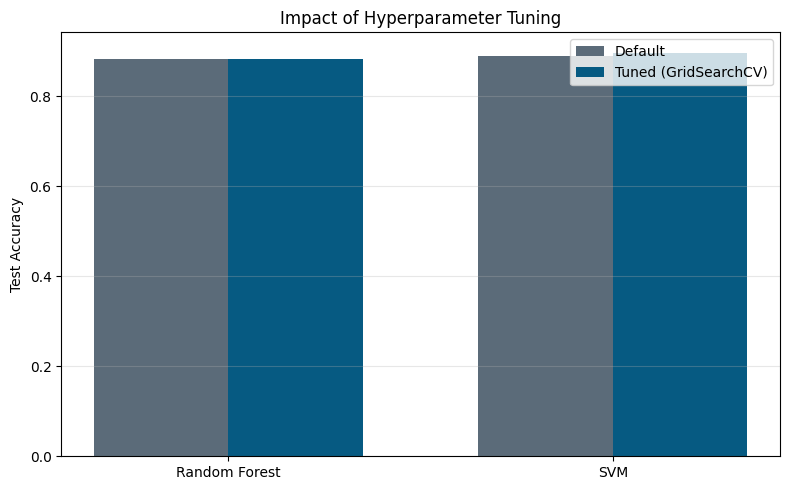

In [ ]:
x = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, summary["Default Hyperparameters Accuracy"], width, label="Default", color="#5B6B79")
ax.bar(x + width/2, summary["Tuned Hyperparameters Accuracy"], width, label="Tuned (GridSearchCV)", color="#065A82")
ax.set_xticks(x)
ax.set_xticklabels(summary["Model"])
ax.set_ylabel("Test Accuracy")
ax.set_title("Impact of Hyperparameter Tuning")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()